In [ ]:
import requests
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================

STATE_FIPS = "06"

JURISDICTIONS = [
    "Stockton city, California",
    "Lodi city, California",
    "Tracy city, California",
    "Manteca city, California",
    "Lathrop city, California",
    "Ripon city, California",
    "Escalon city, California",
]

# Census population variables
POP_VARS = {
    2000: ("2000/dec/sf1", "P001001"),
    2010: ("2010/dec/sf1", "P001001"),
    2020: ("2020/dec/pl", "P1_001N"),
}

# ============================================================
# FETCH FUNCTION
# ============================================================

def fetch_population(year):

    dataset, pop_var = POP_VARS[year]

    url = f"https://api.census.gov/data/{dataset}"

    params = {
        "get": f"NAME,{pop_var}",
        "for": "place:*",
        "in": f"state:{STATE_FIPS}",
    }

    r = requests.get(url, params=params)
    r.raise_for_status()

    data = r.json()

    df = pd.DataFrame(data[1:], columns=data[0])

    df[pop_var] = pd.to_numeric(df[pop_var])

    df = df[df["NAME"].isin(JURISDICTIONS)].copy()

    df = df.rename(columns={pop_var: f"pop_{year}"})

    return df[["NAME", f"pop_{year}"]]


# ============================================================
# PULL DATA
# ============================================================

df2000 = fetch_population(2000)
df2010 = fetch_population(2010)
df2020 = fetch_population(2020)

# Merge
df = df2000.merge(df2010, on="NAME").merge(df2020, on="NAME")

df["City"] = df["NAME"].str.replace(" city, California", "", regex=False)

# ============================================================
# GROWTH CALCULATIONS
# ============================================================

df["Change_2000_2010"] = df["pop_2010"] - df["pop_2000"]
df["Pct_2000_2010"] = (df["Change_2000_2010"] / df["pop_2000"]) * 100

df["Change_2010_2020"] = df["pop_2020"] - df["pop_2010"]
df["Pct_2010_2020"] = (df["Change_2010_2020"] / df["pop_2010"]) * 100

# ============================================================
# TOTAL ACROSS ALL CITIES
# ============================================================

total_2000 = df["pop_2000"].sum()
total_2010 = df["pop_2010"].sum()
total_2020 = df["pop_2020"].sum()

pct_00_10 = (total_2010 - total_2000) / total_2000 * 100
pct_10_20 = (total_2020 - total_2010) / total_2010 * 100

# ============================================================
# OUTPUT
# ============================================================

print("\nCity Growth 2000 → 2010")
print(df[["City","pop_2000","pop_2010","Pct_2000_2010"]])

print("\nCity Growth 2010 → 2020")
print(df[["City","pop_2010","pop_2020","Pct_2010_2020"]])

print("\nTOTAL ACROSS ALL CITIES")
print(f"2000: {total_2000:,}")
print(f"2010: {total_2010:,}")
print(f"2020: {total_2020:,}")

print("\nPercent Change")
print(f"2000 → 2010: {pct_00_10:.2f}%")
print(f"2010 → 2020: {pct_10_20:.2f}%")


City Growth 2000 → 2010
       City  pop_2000  pop_2010  Pct_2000_2010
0   Escalon      5963      7132      19.604226
1   Lathrop     10445     18023      72.551460
2      Lodi     56999     62134       9.008930
3   Manteca     49258     67096      36.213407
4     Ripon     10146     14297      40.912675
5  Stockton    243771    291707      19.664357
6     Tracy     56929     82922      45.658627

City Growth 2010 → 2020
       City  pop_2010  pop_2020  Pct_2010_2020
0   Escalon      7132      7472       4.767246
1   Lathrop     18023     28701      59.246518
2      Lodi     62134     66348       6.782116
3   Manteca     67096     83498      24.445571
4     Ripon     14297     16013      12.002518
5  Stockton    291707    320804       9.974735
6     Tracy     82922     93000      12.153590

TOTAL ACROSS ALL CITIES
2000: 433,511
2010: 543,311
2020: 615,836

Percent Change
2000 → 2010: 25.33%
2010 → 2020: 13.35%


In [ ]:
#Chapter 2 Table 3
import socket
import requests.packages.urllib3.util.connection as urllib3_cn
import requests
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
ACS_YEAR = 2023
ACS_DATASET = "acs/acs5"   # 2023 ACS 5-year (DETAILED TABLES)
STATE_FIPS = "06"          # CA
COUNTY_FIPS = "077"        # San Joaquin County
CENSUS_API_KEY = ""        # optional

JURISDICTIONS = [
    "Stockton city, California",
    "Lodi city, California",
    "Lathrop city, California",
    "Manteca city, California",
    "Escalon city, California",
    "Ripon city, California",
    "Tracy city, California",
    "Mountain House CDP, California",
]

OUT_XLSX = "Age_and_Income_2023_Crosscheck.xlsx"

# ============================================================
# ACS VARIABLES
# ============================================================
# Total population
POP_TOTAL = "B01003_001E"

# Persons age 65+ from B01001 (Sex by Age)
AGE65_CODES = [
    # Male: 65-66, 67-69, 70-74, 75-79, 80-84, 85+
    "B01001_020E","B01001_021E","B01001_022E","B01001_023E","B01001_024E","B01001_025E",
    # Female: 65-66, 67-69, 70-74, 75-79, 80-84, 85+
    "B01001_044E","B01001_045E","B01001_046E","B01001_047E","B01001_048E","B01001_049E",
]

# Poverty (B17001: Poverty Status in past 12 months)
# IMPORTANT: Poverty % = below poverty / poverty universe
POV_UNIVERSE = "B17001_001E"
POV_BELOW = "B17001_002E"

GET_VARS = [POP_TOTAL, POV_UNIVERSE, POV_BELOW] + AGE65_CODES

# ============================================================
# API FETCH
# ============================================================
def fetch_acs(year, dataset, get_vars, for_clause, in_clause=None, api_key=""):
    url = f"https://api.census.gov/data/{year}/{dataset}"
    params = {
        "get": ",".join(["NAME"] + get_vars),
        "for": for_clause,
    }
    if in_clause:
        params["in"] = in_clause
    if api_key:
        params["key"] = api_key

    r = requests.get(url, params=params, timeout=120)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data[1:], columns=data[0])

def to_numeric(df, cols):
    for c in cols:
        df[c] = pd.to_numeric(df[c], errors="coerce")
    return df

# ============================================================
# BUILD TABLE
# ============================================================
def build_age_income_table(df_geo):
    df_geo = df_geo.copy()

    # totals
    df_geo["Population"] = df_geo[POP_TOTAL]
    df_geo["Persons Age 65+"] = df_geo[AGE65_CODES].sum(axis=1, skipna=True)

    # % 65+
    df_geo["Percentage of Age 65+"] = (df_geo["Persons Age 65+"] / df_geo["Population"]) * 100

    # ---- FIXED POVERTY CALCULATION ----
    # Poverty % = Below poverty / Poverty universe
    df_geo["Poverty Universe"] = df_geo[POV_UNIVERSE]
    df_geo["Below Poverty (count)"] = df_geo[POV_BELOW]
    df_geo["Persons in Poverty (%)"] = (df_geo["Below Poverty (count)"] / df_geo["Poverty Universe"]) * 100

    out = df_geo[
        ["NAME", "Population", "Percentage of Age 65+", "Persons Age 65+", "Persons in Poverty (%)",
         "Below Poverty (count)", "Poverty Universe"]
    ].copy()

    # formatting similar to your screenshot
    out = out.rename(columns={"NAME": "Local Jurisdiction"})
    out["Population"] = out["Population"].round(0).astype("Int64")
    out["Persons Age 65+"] = out["Persons Age 65+"].round(0).astype("Int64")
    out["Percentage of Age 65+"] = out["Percentage of Age 65+"].round(2)
    out["Persons in Poverty (%)"] = out["Persons in Poverty (%)"].round(2)

    return out

# ============================================================
# 1) PLACES (cities + CDPs)
# ============================================================
places = fetch_acs(
    ACS_YEAR, ACS_DATASET, GET_VARS,
    for_clause="place:*",
    in_clause=f"state:{STATE_FIPS}",
    api_key=CENSUS_API_KEY,
)
places = to_numeric(places, GET_VARS)
places_sj = places[places["NAME"].isin(JURISDICTIONS)].copy()

# ============================================================
# 2) COUNTY TOTAL
# ============================================================
county = fetch_acs(
    ACS_YEAR, ACS_DATASET, GET_VARS,
    for_clause=f"county:{COUNTY_FIPS}",
    in_clause=f"state:{STATE_FIPS}",
    api_key=CENSUS_API_KEY,
)
county = to_numeric(county, GET_VARS)
county.loc[:, "NAME"] = "San Joaquin County"

# ============================================================
# 3) FINAL OUTPUT (match your table order)
# ============================================================
tbl_places = build_age_income_table(places_sj)
tbl_county = build_age_income_table(county)

order = JURISDICTIONS + ["San Joaquin County"]
age_income_2023 = pd.concat([tbl_places, tbl_county], ignore_index=True)
age_income_2023["__order__"] = age_income_2023["Local Jurisdiction"].map({n: i for i, n in enumerate(order)})
age_income_2023 = age_income_2023.sort_values("__order__").drop(columns="__order__").reset_index(drop=True)

display(age_income_2023)

,Local Jurisdiction,Population,Percentage of Age 65+,Persons Age 65+,Persons in Poverty (%),Below Poverty (count),Poverty Universe
0,"Stockton city, California",320470,13.00,41666,15.37,48496,315431
1,"Lodi city, California",67008,15.43,10339,13.50,8955,66325
2,"Lathrop city, California",32696,10.32,3374,8.56,2740,32012
3,"Manteca city, California",86521,13.61,11779,10.39,8941,86064
4,"Escalon city, California",7429,17.54,1303,9.52,707,7429
5,"Ripon city, California",16117,15.91,2564,3.53,565,15989
6,"Tracy city, California",95358,10.66,10163,7.67,7261,94715
7,"Mountain House CDP, California",25108,6.87,1726,2.68,670,24999
8,San Joaquin County,787416,13.27,104481,12.56,97063,773079


In [ ]:
# Optional: save to Excel for side-by-side cross-checking
OUT_XLSX = "Age_and_Income_2023_SJCOG_Crosscheck.xlsx"
age_income_2023.to_excel(OUT_XLSX, index=False)
print(f"✅ Saved Excel: {OUT_XLSX}")

In [ ]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "DejaVu Sans"
})

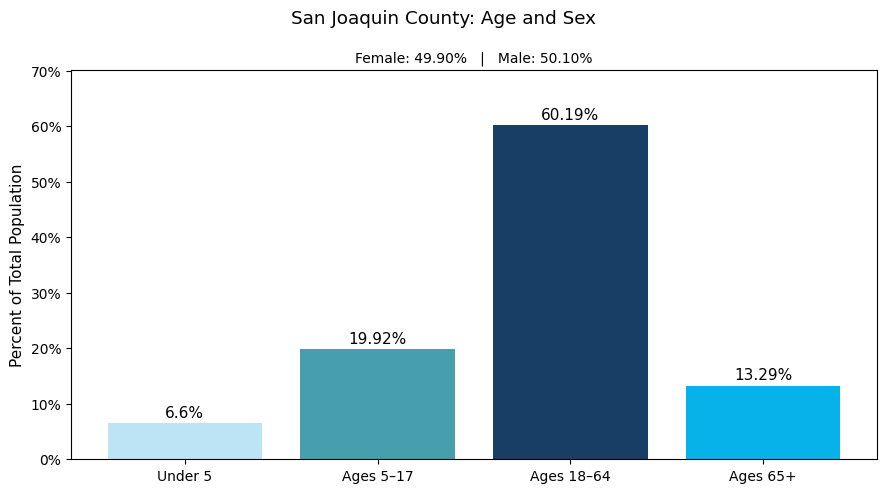

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
ACS_YEAR = 2023
ACS_DATASET = "acs/acs5"
STATE_FIPS = "06"      # California
COUNTY_FIPS = "077"    # San Joaquin County
CENSUS_API_KEY = ""    # optional

# ============================================================
# HELPERS (TRUNCATE, NOT ROUND)
# ============================================================
def to_bps_trunc(percent_value):
    """Truncate percent to 2 decimals using integer basis points (bps)."""
    return int(np.floor(float(percent_value) * 100))

def bps_to_pct(bps):
    return bps / 100

def fmt_pct(value, decimals=2, strip_trailing_zeros=True):
    """Format already-truncated numeric percent without rounding up."""
    s = f"{float(value):.{decimals}f}"
    if strip_trailing_zeros:
        s = s.rstrip("0").rstrip(".")
    return f"{s}%"

# ============================================================
# BUILD B01001 VAR LIST (001..049)
# ============================================================
def b01001_var(i):
    return f"B01001_{i:03d}E"

B01001_VARS = [b01001_var(i) for i in range(1, 50)]  # 001E..049E
TOTAL_POP = "B01001_001E"
MALE_TOTAL = "B01001_002E"
FEMALE_TOTAL = "B01001_026E"

# ============================================================
# FETCH COUNTY DATA
# ============================================================
def fetch_b01001_county():
    url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
    params = {
        "get": ",".join(["NAME"] + B01001_VARS),
        "for": f"county:{COUNTY_FIPS}",
        "in": f"state:{STATE_FIPS}",
    }
    if CENSUS_API_KEY:
        params["key"] = CENSUS_API_KEY

    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()
    df = pd.DataFrame(data[1:], columns=data[0])
    for v in B01001_VARS:
        df[v] = pd.to_numeric(df[v], errors="coerce")
    return df

df = fetch_b01001_county()

total_pop = df.loc[0, TOTAL_POP]
male_total = df.loc[0, MALE_TOTAL]
female_total = df.loc[0, FEMALE_TOTAL]

# ============================================================
# AGE GROUP COUNTS (B01001)
# ============================================================
under5 = df.loc[0, "B01001_003E"] + df.loc[0, "B01001_027E"]

age5_17 = (
    df.loc[0, "B01001_004E"] + df.loc[0, "B01001_005E"] + df.loc[0, "B01001_006E"] +
    df.loc[0, "B01001_028E"] + df.loc[0, "B01001_029E"] + df.loc[0, "B01001_030E"]
)

age18_64 = (
    df.loc[0, [f"B01001_{i:03d}E" for i in range(7, 20)]].sum() +
    df.loc[0, [f"B01001_{i:03d}E" for i in range(31, 44)]].sum()
)

age65p = (
    df.loc[0, [f"B01001_{i:03d}E" for i in range(20, 26)]].sum() +
    df.loc[0, [f"B01001_{i:03d}E" for i in range(44, 50)]].sum()
)

# ============================================================
# PERCENTAGES (NO ROUND-UP, EXACTLY SUM TO 100.00)
# ============================================================
p_under5_raw = (under5 / total_pop) * 100
p_5_17_raw   = (age5_17 / total_pop) * 100
p_18_64_raw  = (age18_64 / total_pop) * 100
p_65p_raw    = (age65p / total_pop) * 100

bps_under5 = to_bps_trunc(p_under5_raw)
bps_5_17   = to_bps_trunc(p_5_17_raw)
bps_18_64  = to_bps_trunc(p_18_64_raw)

# Force remainder so total is EXACTLY 10000 bps (=100.00%)
bps_65p = 10000 - (bps_under5 + bps_5_17 + bps_18_64)

p_under5 = bps_to_pct(bps_under5)
p_5_17   = bps_to_pct(bps_5_17)
p_18_64  = bps_to_pct(bps_18_64)
p_65p    = bps_to_pct(bps_65p)

# Sex % (also exact 100.00 using bps)
female_bps = to_bps_trunc((female_total / total_pop) * 100)
male_bps   = 10000 - female_bps
female_pct = bps_to_pct(female_bps)
male_pct   = bps_to_pct(male_bps)

# ============================================================
# BAR CHART
# ============================================================
age_groups = ["Under 5", "Ages 5–17", "Ages 18–64", "Ages 65+"]
percentages = [p_under5, p_5_17, p_18_64, p_65p]

plt.figure(figsize=(9, 5))
colors = ["#bde4f4", "#479ead", "#193e66", "#07b2eb"]
bars = plt.bar(age_groups, percentages, color=colors)

plt.ylabel("Percent of Total Population")
plt.ylim(0, max(70, (max(percentages) + 10)))
plt.yticks(np.arange(0, 71, 10), [f"{i}%" for i in range(0, 71, 10)])

plt.suptitle("San Joaquin County: Age and Sex", y=0.98)
plt.title(f"Female: {female_pct:.2f}%   |   Male: {male_pct:.2f}%", fontsize=10)

# labels above bars: show up to 2 decimals, don't force .00, no rounding-up
for bar, pct in zip(bars, percentages):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        fmt_pct(pct, decimals=2, strip_trailing_zeros=True),
        ha="center"
    )

plt.tight_layout()
plt.show()

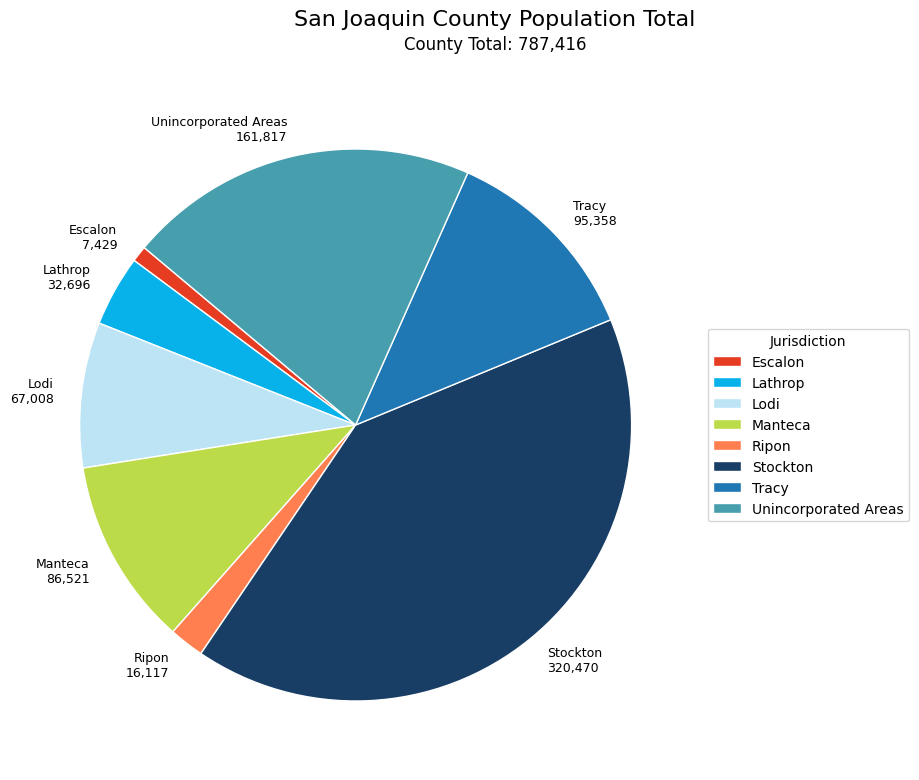

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# SETTINGS
# ============================================================
ACS_YEAR = 2023
ACS_DATASET = "acs/acs5"
STATE_FIPS = "06"     # California
COUNTY_FIPS = "077"   # San Joaquin County
POP_VAR = "B01003_001E"

CITIES = [
    "Stockton city, California",
    "Lodi city, California",
    "Lathrop city, California",
    "Manteca city, California",
    "Escalon city, California",
    "Ripon city, California",
    "Tracy city, California",
]

# ============================================================
# FETCH ALL PLACES IN CA
# ============================================================
def fetch_places():
    url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
    params = {
        "get": f"NAME,{POP_VAR}",
        "for": "place:*",
        "in": f"state:{STATE_FIPS}",
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data[1:], columns=data[0])

# ============================================================
# FETCH COUNTY TOTAL
# ============================================================
def fetch_county():
    url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
    params = {
        "get": f"NAME,{POP_VAR}",
        "for": f"county:{COUNTY_FIPS}",
        "in": f"state:{STATE_FIPS}",
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()
    return int(data[1][1])

# ============================================================
# PULL DATA
# ============================================================
places_df = fetch_places()
places_df[POP_VAR] = pd.to_numeric(places_df[POP_VAR], errors="coerce")

city_df = places_df[places_df["NAME"].isin(CITIES)].copy()

pop_data = {}
for _, row in city_df.iterrows():
    clean_name = row["NAME"].split(" city")[0]
    pop_data[clean_name] = int(row[POP_VAR])

county_total = fetch_county()

incorporated_total = sum(pop_data.values())
unincorporated = county_total - incorporated_total
pop_data["Unincorporated Areas"] = unincorporated

# ============================================================
# PREP PIE DATA
# ============================================================
labels = [
    f"{name}\n{value:,}"
    for name, value in pop_data.items()
]
sizes = list(pop_data.values())

colors = [
    "#e53c22",  # Escalon (red - smallest)
    "#07b2eb",  # Lathrop
    "#bde4f4",  # Lodi
    "#bcdb49",  # Manteca
    "#ff7f50",  # Ripon
    "#193e66",  # Stockton
    "#1f77b4",  # Tracy (blue but different from Lathrop)
    "#479ead",  # Unincorporated Areas
]
# ============================================================
# PLOT
# ============================================================
fig = plt.figure(figsize=(10, 8))

wedges, texts = plt.pie(
    sizes,
    labels=labels,
    colors=colors,
    startangle=140,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 9}
)

# Centered Main Title
fig.text(
    0.5, 0.95,
    "San Joaquin County Population Total",
    ha="center",
    fontsize=16
)

# Centered County Total directly below
fig.text(
    0.5, 0.92,
    f"County Total: {county_total:,}",
    ha="center",
    fontsize=12
)

# Legend (color only)
plt.legend(
    wedges,
    pop_data.keys(),
    title="Jurisdiction",
    loc="center left",
    bbox_to_anchor=(1, 0.5)
)

plt.tight_layout(rect=[0, 0, 0.85, 0.9])
plt.show()



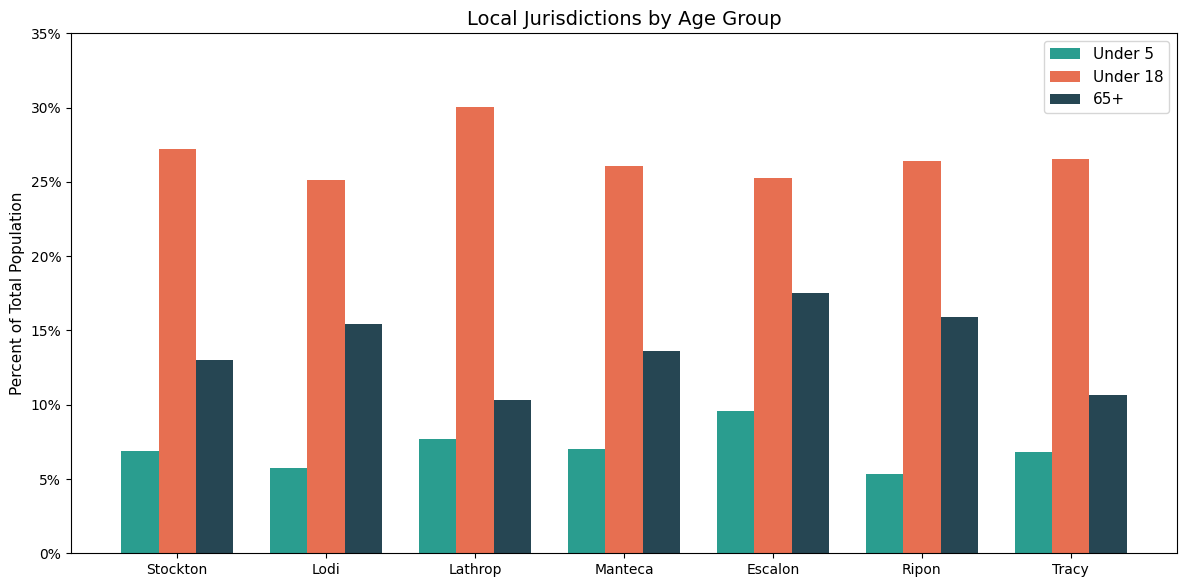

In [ ]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# SETTINGS
# ============================================================
ACS_YEAR = 2023
ACS_DATASET = "acs/acs5"
STATE_FIPS = "06"

CITIES_ORDER = [
    "Stockton city, California",
    "Lodi city, California",
    "Lathrop city, California",
    "Manteca city, California",
    "Escalon city, California",
    "Ripon city, California",
    "Tracy city, California"
]

# B01001 Variables
POP_VARS = [
    "B01001_001E",  # Total population

    # Under 18 (Male)
    "B01001_003E","B01001_004E","B01001_005E","B01001_006E",
    # 65+ (Male)
    "B01001_020E","B01001_021E","B01001_022E",
    "B01001_023E","B01001_024E","B01001_025E",

    # Under 18 (Female)
    "B01001_027E","B01001_028E","B01001_029E","B01001_030E",
    # 65+ (Female)
    "B01001_044E","B01001_045E","B01001_046E",
    "B01001_047E","B01001_048E","B01001_049E"
]

# ============================================================
# FETCH DATA
# ============================================================
def fetch_places():
    url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
    params = {
        "get": ",".join(["NAME"] + POP_VARS),
        "for": "place:*",
        "in": f"state:{STATE_FIPS}",
    }
    r = requests.get(url, params=params)
    r.raise_for_status()
    data = r.json()
    return pd.DataFrame(data[1:], columns=data[0])

df = fetch_places()

# Convert to numeric
for col in POP_VARS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# Filter and enforce city order
df = df[df["NAME"].isin(CITIES_ORDER)].copy()
df = df.set_index("NAME").loc[CITIES_ORDER].reset_index()

# ============================================================
# CALCULATE AGE GROUP PERCENTAGES
# ============================================================
results = []

for _, row in df.iterrows():
    total = row["B01001_001E"]

    under5 = row["B01001_003E"] + row["B01001_027E"]

    under18 = (
        row["B01001_003E"] + row["B01001_004E"] + row["B01001_005E"] + row["B01001_006E"] +
        row["B01001_027E"] + row["B01001_028E"] + row["B01001_029E"] + row["B01001_030E"]
    )

    age65p = (
        row["B01001_020E"] + row["B01001_021E"] + row["B01001_022E"] +
        row["B01001_023E"] + row["B01001_024E"] + row["B01001_025E"] +
        row["B01001_044E"] + row["B01001_045E"] + row["B01001_046E"] +
        row["B01001_047E"] + row["B01001_048E"] + row["B01001_049E"]
    )

    results.append([
        row["NAME"].split(" city")[0],
        (under5 / total) * 100,
        (under18 / total) * 100,
        (age65p / total) * 100
    ])

results_df = pd.DataFrame(results, columns=["City","Under5","Under18","Age65plus"])

# ============================================================
# PLOT
# ============================================================
x = np.arange(len(results_df["City"]))
width = 0.25

fig, ax = plt.subplots(figsize=(12,6))

# Clean modern color palette
bars1 = ax.bar(x - width, results_df["Under5"], width,
               label="Under 5",
               color="#2A9D8F")

bars2 = ax.bar(x, results_df["Under18"], width,
               label="Under 18",
               color="#E76F51")

bars3 = ax.bar(x + width, results_df["Age65plus"], width,
               label="65+",
               color="#264653")

ax.set_xticks(x)
ax.set_xticklabels(results_df["City"])

ax.set_ylabel("Percent of Total Population")
ax.set_ylim(0, 35)
ax.set_yticks(np.arange(0, 36, 5))
ax.set_yticklabels([f"{i}%" for i in range(0, 36, 5)])

ax.set_title("Local Jurisdictions by Age Group", fontsize=14)

ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import requests
import pandas as pd

# ============================================================
# SETTINGS
# ============================================================
ACS_YEAR = 2023
ACS_DATASET = "acs/acs5"
STATE_FIPS = "06"
COUNTY_FIPS = "077"

# B01001 variables needed
VARS = [
    "B01001_001E",  # Total population

    # Under 18 (Male)
    "B01001_003E","B01001_004E","B01001_005E","B01001_006E",
    # Under 18 (Female)
    "B01001_027E","B01001_028E","B01001_029E","B01001_030E",

    # 18+ Total
    "B01001_007E","B01001_008E","B01001_009E","B01001_010E",
    "B01001_011E","B01001_012E","B01001_013E","B01001_014E",
    "B01001_015E","B01001_016E","B01001_017E","B01001_018E",
    "B01001_019E","B01001_020E","B01001_021E","B01001_022E",
    "B01001_023E","B01001_024E","B01001_025E",

    "B01001_031E","B01001_032E","B01001_033E","B01001_034E",
    "B01001_035E","B01001_036E","B01001_037E","B01001_038E",
    "B01001_039E","B01001_040E","B01001_041E","B01001_042E",
    "B01001_043E","B01001_044E","B01001_045E","B01001_046E",
    "B01001_047E","B01001_048E","B01001_049E"
]

# ============================================================
# FETCH DATA
# ============================================================
url = f"https://api.census.gov/data/{ACS_YEAR}/{ACS_DATASET}"
params = {
    "get": ",".join(["NAME"] + VARS),
    "for": f"county:{COUNTY_FIPS}",
    "in": f"state:{STATE_FIPS}",
}

response = requests.get(url, params=params)
response.raise_for_status()
data = response.json()

df = pd.DataFrame(data[1:], columns=data[0])

for col in VARS:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# CALCULATIONS
# ============================================================
total_pop = df.loc[0, "B01001_001E"]

under18 = (
    df.loc[0, "B01001_003E"] + df.loc[0, "B01001_004E"] +
    df.loc[0, "B01001_005E"] + df.loc[0, "B01001_006E"] +
    df.loc[0, "B01001_027E"] + df.loc[0, "B01001_028E"] +
    df.loc[0, "B01001_029E"] + df.loc[0, "B01001_030E"]
)

over18 = total_pop - under18

# ------------------------------------------------------------
# INSERT DMV LICENSE DATA HERE
# Replace this number with actual DMV value
# ------------------------------------------------------------
licensed_drivers = 473213  # <-- UPDATE WITH 2023 DMV DATA

without_license = over18 - licensed_drivers

# ============================================================
# BUILD CLEAN TABLE
# ============================================================
table = pd.DataFrame({
    "San Joaquin Residents": [
        "San Joaquin County Population",
        "Number of Licensed Drivers",
        "Population Under 18",
        "Population 18 and Over",
        "Population 18+ Without a Driver’s License"
    ],
    "Population": [
        f"{int(total_pop):,}",
        f"{int(licensed_drivers):,}",
        f"{int(under18):,}",
        f"{int(over18):,}",
        f"{int(without_license):,}"
    ]
})

print(table.to_string(index=False))


In [ ]:
import os
import requests

# -----------------------------
# ACS 2023 5-year: San Joaquin County, CA
# -----------------------------
YEAR = "2023"
DATASET = "acs/acs5"
STATE_FIPS = "06"    # California
COUNTY_FIPS = "077"  # San Joaquin County

# Optional (recommended) Census API key:
# set env var: CENSUS_API_KEY="YOUR_KEY"
API_KEY = os.getenv("CENSUS_API_KEY", "").strip()

BASE_URL = f"https://api.census.gov/data/{YEAR}/{DATASET}"

# --- Variables needed for "Under 18" from B01001 (Sex by Age) ---
UNDER18_VARS = [
    # Male: Under 5, 5-9, 10-14, 15-17
    "B01001_003E", "B01001_004E", "B01001_005E", "B01001_006E",
    # Female: Under 5, 5-9, 10-14, 15-17
    "B01001_027E", "B01001_028E", "B01001_029E", "B01001_030E",
]

# Total population (for 18+ = total - under18)
TOTALPOP_VAR = "B01003_001E"  # Total population

def fetch_acs(vars_list):
    params = {
        "get": ",".join(["NAME"] + vars_list),
        "for": f"county:{COUNTY_FIPS}",
        "in": f"state:{STATE_FIPS}",
    }
    if API_KEY:
        params["key"] = API_KEY

    r = requests.get(BASE_URL, params=params, timeout=30)
    r.raise_for_status()
    data = r.json()

    # First row is header; second row is values
    header = data[0]
    values = data[1]
    return dict(zip(header, values))

def to_int(x):
    # Census returns strings; sometimes missing values appear as null-like
    try:
        return int(float(x))
    except Exception:
        return 0

def main():
    # Pull total pop + under18 components in one request
    vars_needed = [TOTALPOP_VAR] + UNDER18_VARS
    row = fetch_acs(vars_needed)

    name = row.get("NAME", "Unknown")
    total_pop = to_int(row.get(TOTALPOP_VAR))
    under18 = sum(to_int(row.get(v)) for v in UNDER18_VARS)
    over18 = total_pop - under18

    print(f"Geography: {name}")
    print(f"Total population: {total_pop:,}")
    print(f"Population under 18: {under18:,}")
    print(f"Population 18 and over (Total - Under 18): {over18:,}")

if __name__ == "__main__":
    main()
